In [1]:
# 04 - Inferential Statistics

"""This notebook performs inferential statistical analysis on e-commerce price data.

Main objectives:
- Test whether price distributions follow a normal distribution
- Compare prices between e-commerce websites
- Compare prices across product categories
- Analyze relationships between price, rating, and review count
- Build and interpret a regression model"""

'This notebook performs inferential statistical analysis on e-commerce price data.\n\nMain objectives:\n- Test whether price distributions follow a normal distribution\n- Compare prices between e-commerce websites\n- Compare prices across product categories\n- Analyze relationships between price, rating, and review count\n- Build and interpret a regression model'

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from google.cloud import bigquery

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
PROJECT_ID = "price-intel-prod"
DATASET_ID = "price_staging"

client = bigquery.Client(project=PROJECT_ID)

query_clean = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.clean_prices`
"""

df_clean = client.query(query_clean).to_dataframe()
df_clean["scraped_at"] = pd.to_datetime(df_clean["scraped_at"])

c:\Users\Usuario\Desktop\analytics\venv\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
c:\Users\Usuario\Desktop\analytics\venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [4]:
# adding a log version of the price, because our prices are very asymmetrical

df_clean["log_price"] = np.log1p(df_clean["price"])

In [6]:
df_clean[["price", "log_price", "site_name", "category", "rating", "review_count"]]

,price,log_price,site_name,category,rating,review_count
0,299.0,5.703782,electroplanet,adaptateurs,NaN,<NA>
1,299.0,5.703782,electroplanet,adaptateurs,NaN,<NA>
2,299.0,5.703782,electroplanet,adaptateurs,NaN,<NA>
3,299.0,5.703782,electroplanet,adaptateurs,NaN,<NA>
4,299.0,5.703782,electroplanet,adaptateurs,NaN,<NA>
...,...,...,...,...,...,...
10518,190.0,5.252273,jumia_ma,tablettes-tactiles,5.0,1
10519,177.0,5.181784,jumia_ma,tablettes-tactiles,5.0,1
10520,190.0,5.252273,jumia_ma,tablettes-tactiles,5.0,1
10521,190.0,5.252273,jumia_ma,tablettes-tactiles,5.0,1


In [7]:
## Normality Test

"""Before comparing prices between websites or categories, we test whether the price distribution follows a normal distribution.

Hypotheses:

- H0: Prices follow a normal distribution.
- H1: Prices do not follow a normal distribution."""

'Before comparing prices between websites or categories, we test whether the price distribution follows a normal distribution.\n\nHypotheses:\n\n- H0: Prices follow a normal distribution.\n- H1: Prices do not follow a normal distribution.'

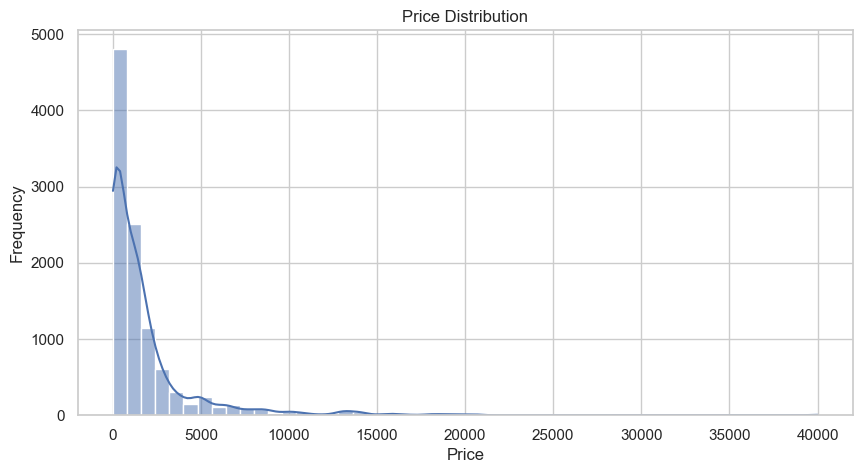

In [8]:
#Visualizing the distribution

plt.figure(figsize=(10, 5))
sns.histplot(df_clean["price"], bins=50, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

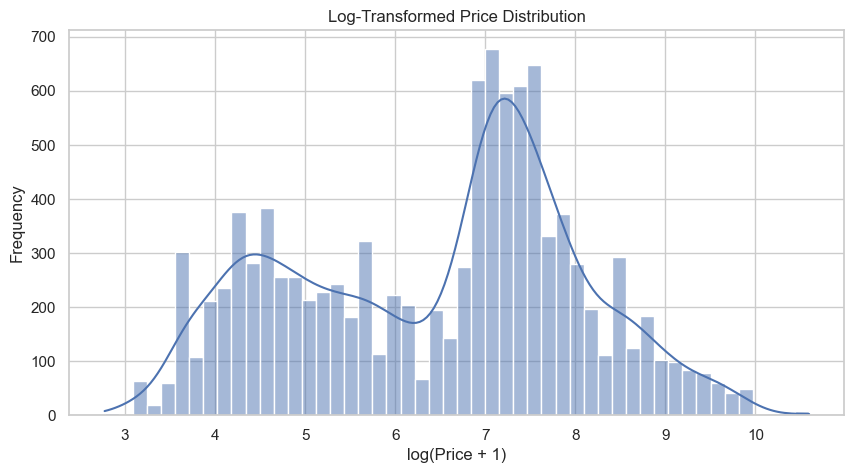

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["log_price"], bins=50, kde=True)
plt.title("Log-Transformed Price Distribution")
plt.xlabel("log(Price + 1)")
plt.ylabel("Frequency")
plt.show()

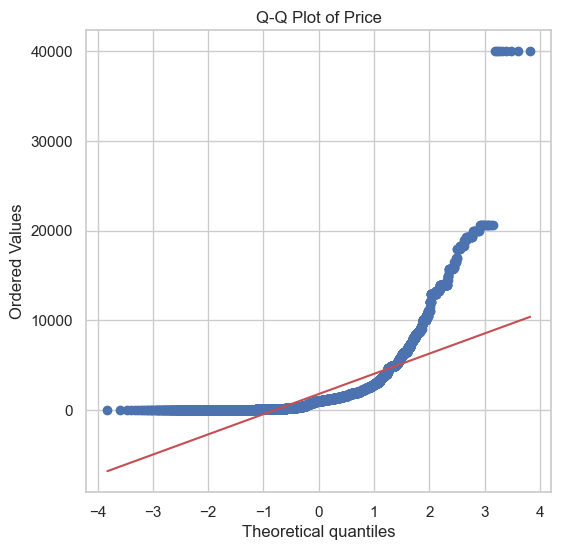

In [10]:
# Q-Q plot

plt.figure(figsize=(6, 6))
stats.probplot(df_clean["price"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Price")
plt.show()

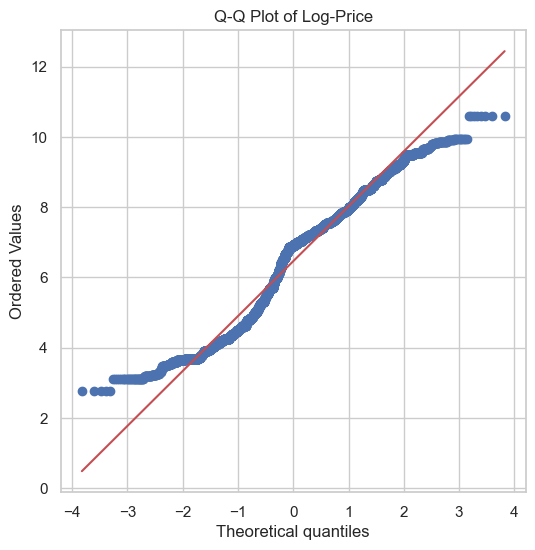

In [11]:
plt.figure(figsize=(6, 6))
stats.probplot(df_clean["log_price"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Log-Price")
plt.show()

In [12]:
# Shapiro-Wilk test on a sample

price_sample = df_clean["price"].dropna().sample(n=5000, random_state=42)
log_price_sample = df_clean["log_price"].dropna().sample(n=5000, random_state=42)

shapiro_price = stats.shapiro(price_sample)
shapiro_log_price = stats.shapiro(log_price_sample)

shapiro_results = {
    "price_statistic": shapiro_price.statistic,
    "price_p_value": shapiro_price.pvalue,
    "log_price_statistic": shapiro_log_price.statistic,
    "log_price_p_value": shapiro_log_price.pvalue
}

shapiro_results

{'price_statistic': np.float64(0.5863873693049213),
 'price_p_value': np.float64(4.215891173520485e-76),
 'log_price_statistic': np.float64(0.9626421356109526),
 'log_price_p_value': np.float64(4.386300709676526e-34)}

In [13]:
alpha = 0.05

if shapiro_price.pvalue < alpha:
    print("Price is not normally distributed (reject H0).")
else:
    print("Price appears normally distributed (fail to reject H0).")

if shapiro_log_price.pvalue < alpha:
    print("Log-price is not normally distributed (reject H0).")
else:
    print("Log-price appears normally distributed (fail to reject H0).")

Price is not normally distributed (reject H0).
Log-price is not normally distributed (reject H0).


In [14]:
"""The Shapiro-Wilk normality test was applied to a random sample of 5,000 observations. For both the original price variable and the log-transformed price variable, the p-values are far below 0.05. Therefore, we reject the null hypothesis of normality.

Although the log transformation improves the shape of the distribution, the log-price variable still does not follow a normal distribution according to the test. As a result, non-parametric tests are more appropriate for comparing prices between groups."""

'The Shapiro-Wilk normality test was applied to a random sample of 5,000 observations. For both the original price variable and the log-transformed price variable, the p-values are far below 0.05. Therefore, we reject the null hypothesis of normality.\n\nAlthough the log transformation improves the shape of the distribution, the log-price variable still does not follow a normal distribution according to the test. As a result, non-parametric tests are more appropriate for comparing prices between groups.'

In [15]:
# Price comparison between Jumia and Electroplanet
## Website Price Comparison: Mann-Whitney U Test

"""Since the price distribution is not normal, a non-parametric Mann-Whitney U test is used to compare prices between Jumia Morocco and Electroplanet.

Hypotheses:

- H0: The price distributions of the two websites are similar.
- H1: The price distributions of the two websites are significantly different."""



'Since the price distribution is not normal, a non-parametric Mann-Whitney U test is used to compare prices between Jumia Morocco and Electroplanet.\n\nHypotheses:\n\n- H0: The price distributions of the two websites are similar.\n- H1: The price distributions of the two websites are significantly different.'

In [16]:
#Creating the 2 groups

jumia_prices = df_clean[df_clean["site_name"] == "jumia_ma"]["price"].dropna()
electroplanet_prices = df_clean[df_clean["site_name"] == "electroplanet"]["price"].dropna()

print("Jumia observations:", len(jumia_prices))
print("Electroplanet observations:", len(electroplanet_prices))

Jumia observations: 9938
Electroplanet observations: 585


In [17]:
# Mann-Whitney U test

mannwhitney_site = stats.mannwhitneyu(
    jumia_prices,
    electroplanet_prices,
    alternative="two-sided"
)

mannwhitney_site_results = {
    "u_statistic": mannwhitney_site.statistic,
    "p_value": mannwhitney_site.pvalue,
    "jumia_median": jumia_prices.median(),
    "electroplanet_median": electroplanet_prices.median(),
    "jumia_mean": jumia_prices.mean(),
    "electroplanet_mean": electroplanet_prices.mean()
}

mannwhitney_site_results

{'u_statistic': np.float64(713783.0),
 'p_value': np.float64(3.668713820284383e-207),
 'jumia_median': np.float64(959.0),
 'electroplanet_median': np.float64(5999.0),
 'jumia_mean': np.float64(1461.2778084121553),
 'electroplanet_mean': np.float64(7584.261538461538)}

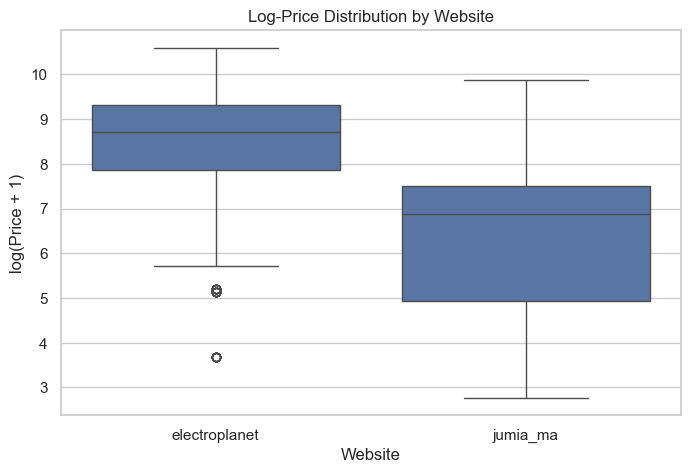

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="site_name", y="log_price")
plt.title("Log-Price Distribution by Website")
plt.xlabel("Website")
plt.ylabel("log(Price + 1)")
plt.show()

In [19]:
# ANOVA was not selected as the main test because the price variable is highly skewed and does not follow a normal distribution. In addition, product categories contain very different price ranges and variances. 
# Therefore, the Kruskal-Wallis test, a non-parametric alternative to one-way ANOVA, is more appropriate for comparing price distributions across categories.

In [20]:
## Category Price Comparison: Kruskal-Wallis Test 

# Since price distributions are not normally distributed, the Kruskal-Wallis test is used to compare prices across product categories.

# Hypotheses:

# - H0: Price distributions are similar across product categories.
# - H1: At least one product category has a significantly different price distribution.

In [22]:
category_counts = df_clean["category"].value_counts()

valid_categories = category_counts[category_counts >= 27].index

category_price_groups = [
    df_clean[df_clean["category"] == category]["price"].dropna()
    for category in valid_categories
]

len(category_price_groups)

18

In [23]:
kruskal_category = stats.kruskal(*category_price_groups)

kruskal_category_results = {
    "h_statistic": kruskal_category.statistic,
    "p_value": kruskal_category.pvalue,
    "number_of_categories": len(valid_categories)
}

kruskal_category_results

{'h_statistic': np.float64(7080.61353535557),
 'p_value': np.float64(0.0),
 'number_of_categories': 18}

In [24]:
# Table of medians by category

# Since Kruskal-Wallis works with rangs, medians are useful for interpretation.

category_median_prices = df_clean[
    df_clean["category"].isin(valid_categories)
].groupby("category")["price"].agg(
    count="count",
    median="median",
    mean="mean",
    min="min",
    max="max"
).reset_index().sort_values("median", ascending=False)

category_median_prices

,category,count,median,mean,min,max
17,ultrabook,27,17999.0,17332.333333,13999.0,19999.0
10,pc-gamer,46,13999.0,18585.760870,9999.0,39999.0
11,pc-hybride,30,11999.0,11999.000000,9999.0,13999.0
7,notebook,111,9499.0,8896.216216,3690.0,12999.0
6,macbook,36,8999.0,12687.916667,7999.0,20590.0
13,tablettes-android,170,2749.0,3751.635294,1590.0,11490.0
2,ecran,131,2599.0,5086.305344,849.0,15999.0
14,tablettes-tactiles,1123,2525.0,3353.933482,79.0,18999.0
16,telephones-smartphones,2711,1499.0,2367.658539,114.0,19275.0
9,ordinateurs-pc,840,1399.0,1821.078571,339.0,7399.0


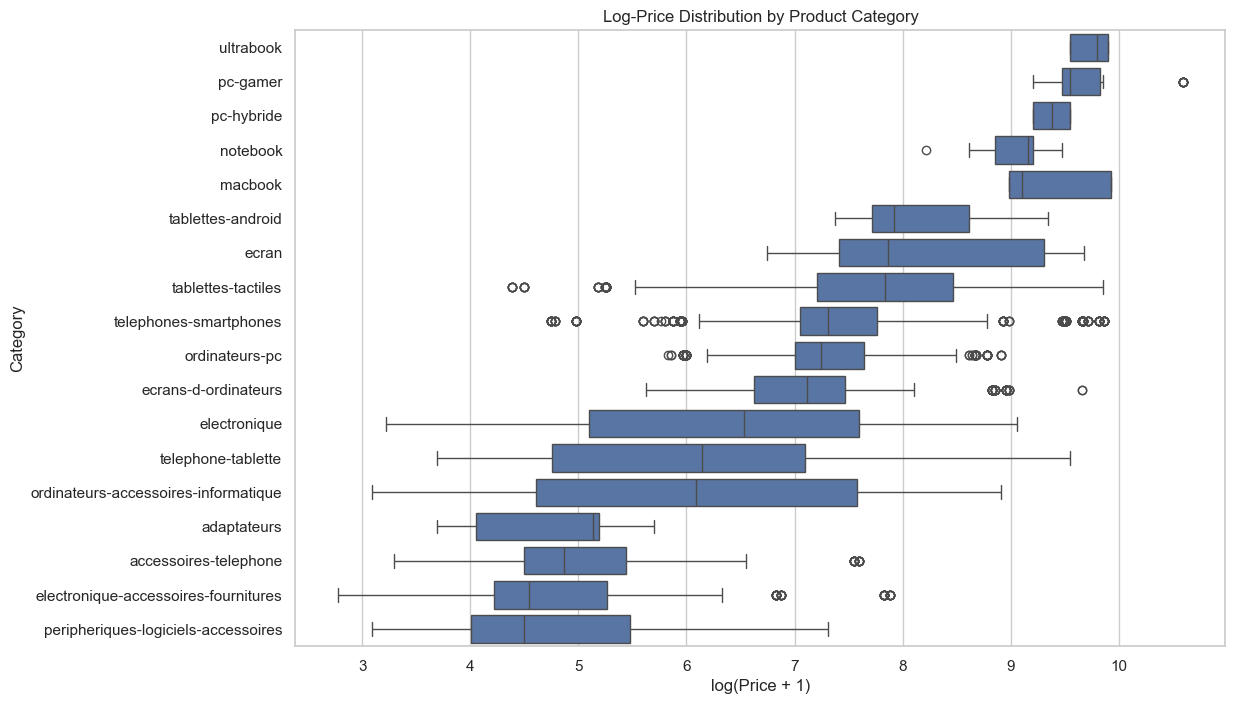

In [25]:
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_clean[df_clean["category"].isin(valid_categories)],
    y="category",
    x="log_price",
    order=category_median_prices["category"]
)
plt.title("Log-Price Distribution by Product Category")
plt.xlabel("log(Price + 1)")
plt.ylabel("Category")
plt.show()

In [ ]:
#The Kruskal-Wallis test indicates a statistically significant difference in price distributions across product categories, with a p-value below 0.05. Therefore, the null hypothesis is rejected.

#This result suggests that product category has a significant effect on observed price levels. The category-level medians confirm this result: high-end categories such as `ultrabook`, `pc-gamer`, `pc-hybride`, `notebook`, and `macbook` have much higher median prices than accessory-related categories such as `peripheriques-logiciels-accessoires`, `electronique-accessoires-fournitures`, and `accessoires-telephone`.

#However, the Kruskal-Wallis test only indicates that at least one category differs from the others. It does not identify exactly which category pairs are significantly different.

In [26]:
# Bonus 
# Post-hoc Pairwise Comparisons Between Categories

# The Kruskal-Wallis test indicates that at least one product category has a significantly different price distribution. However, it does not identify which specific categories differ.

# To investigate this, pairwise Mann-Whitney U tests are performed between categories. Since multiple comparisons are conducted, p-values are adjusted using the Benjamini-Hochberg False Discovery Rate correction.

In [27]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests

In [30]:
# Conduct comparisons two by two

pairwise_results = []

for cat1, cat2 in combinations(valid_categories, 2):
    prices_cat1 = df_clean[df_clean["category"] == cat1]["price"].dropna()
    prices_cat2 = df_clean[df_clean["category"] == cat2]["price"].dropna()
    
    test_result = stats.mannwhitneyu(
        prices_cat1,
        prices_cat2,
        alternative="two-sided"
    )
    
    pairwise_results.append({
        "category_1": cat1,
        "category_2": cat2,
        "u_statistic": test_result.statistic,
        "p_value": test_result.pvalue,
        "median_1": prices_cat1.median(),
        "median_2": prices_cat2.median(),
        "median_difference": prices_cat1.median() - prices_cat2.median()
    })

pairwise_category_tests = pd.DataFrame(pairwise_results)

pairwise_category_tests

,category_1,category_2,u_statistic,p_value,median_1,median_2,median_difference
0,telephones-smartphones,peripheriques-logiciels-accessoires,3894555.5,0.000000e+00,1499.0,89.0,1410.0
1,telephones-smartphones,accessoires-telephone,3308127.5,0.000000e+00,1499.0,129.0,1370.0
2,telephones-smartphones,tablettes-tactiles,1149991.5,7.685404e-33,1499.0,2525.0,-1026.0
3,telephones-smartphones,electronique-accessoires-fournitures,2854930.0,0.000000e+00,1499.0,93.0,1406.0
4,telephones-smartphones,ordinateurs-pc,1241972.0,6.836560e-05,1499.0,1399.0,100.0
...,...,...,...,...,...,...,...
148,macbook,pc-hybride,420.0,1.157773e-01,8999.0,11999.0,-3000.0
149,macbook,ultrabook,306.0,1.133309e-02,8999.0,17999.0,-9000.0
150,adaptateurs,pc-hybride,0.0,2.987100e-12,169.0,11999.0,-11830.0
151,adaptateurs,ultrabook,0.0,1.733226e-11,169.0,17999.0,-17830.0


In [31]:
# Correct p-values

reject, p_adjusted, _, _ = multipletests(
    pairwise_category_tests["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

pairwise_category_tests["p_value_adjusted"] = p_adjusted
pairwise_category_tests["significant"] = reject

pairwise_category_tests = pairwise_category_tests.sort_values(
    "p_value_adjusted"
)

pairwise_category_tests.head(20)

,category_1,category_2,u_statistic,p_value,median_1,median_2,median_difference,p_value_adjusted,significant
0,telephones-smartphones,peripheriques-logiciels-accessoires,3894555.5,0.000000e+00,1499.0,89.0,1410.0,0.000000e+00,True
1,telephones-smartphones,accessoires-telephone,3308127.5,0.000000e+00,1499.0,129.0,1370.0,0.000000e+00,True
3,telephones-smartphones,electronique-accessoires-fournitures,2854930.0,0.000000e+00,1499.0,93.0,1406.0,0.000000e+00,True
18,peripheriques-logiciels-accessoires,tablettes-tactiles,31007.0,0.000000e+00,89.0,2525.0,-2436.0,0.000000e+00,True
20,peripheriques-logiciels-accessoires,ordinateurs-pc,16451.0,0.000000e+00,89.0,1399.0,-1310.0,0.000000e+00,True
33,accessoires-telephone,tablettes-tactiles,32274.0,0.000000e+00,129.0,2525.0,-2396.0,0.000000e+00,True
48,tablettes-tactiles,electronique-accessoires-fournitures,1176054.0,0.000000e+00,2525.0,93.0,2432.0,0.000000e+00,True
35,accessoires-telephone,ordinateurs-pc,14902.0,3.624906e-310,129.0,1399.0,-1270.0,6.932633e-309,True
21,peripheriques-logiciels-accessoires,ecrans-d-ordinateurs,29371.5,9.386880e-292,89.0,1226.0,-1137.0,1.595770e-290,True
62,electronique-accessoires-fournitures,ordinateurs-pc,16340.5,3.304289e-287,93.0,1399.0,-1306.0,5.055563e-286,True


In [32]:
posthoc_summary = {
    "total_pairwise_comparisons": len(pairwise_category_tests),
    "significant_comparisons": pairwise_category_tests["significant"].sum(),
    "non_significant_comparisons": (~pairwise_category_tests["significant"]).sum()
}

posthoc_summary

{'total_pairwise_comparisons': 153,
 'significant_comparisons': np.int64(146),
 'non_significant_comparisons': np.int64(7)}

In [34]:
largest_median_differences = pairwise_category_tests[
    pairwise_category_tests["significant"]
].copy()

largest_median_differences["abs_median_difference"] = (
    largest_median_differences["median_difference"].abs()
)

largest_median_differences = largest_median_differences.sort_values(
    "abs_median_difference",
    ascending=False
)

largest_median_differences.head(10)

,category_1,category_2,u_statistic,p_value,median_1,median_2,median_difference,p_value_adjusted,significant,abs_median_difference
32,peripheriques-logiciels-accessoires,ultrabook,0.0,4.759539e-19,89.0,17999.0,-17910.0,7.282095e-19,True,17910.0
74,electronique-accessoires-fournitures,ultrabook,0.0,6.314920e-19,93.0,17999.0,-17906.0,9.380415e-19,True,17906.0
47,accessoires-telephone,ultrabook,0.0,5.326287e-19,129.0,17999.0,-17870.0,8.068534e-19,True,17870.0
151,adaptateurs,ultrabook,0.0,1.733226e-11,169.0,17999.0,-17830.0,2.071746e-11,True,17830.0
107,ordinateurs-accessoires-informatique,ultrabook,0.0,8.066382e-18,440.0,17999.0,-17559.0,1.092174e-17,True,17559.0
124,telephone-tablette,ultrabook,13.5,4.806796e-17,466.0,17999.0,-17533.0,6.232541e-17,True,17533.0
116,electronique,ultrabook,0.0,1.364743e-17,684.0,17999.0,-17315.0,1.815702e-17,True,17315.0
97,ecrans-d-ordinateurs,ultrabook,18.0,1.115194e-18,1226.0,17999.0,-16773.0,1.579858e-18,True,16773.0
86,ordinateurs-pc,ultrabook,0.0,8.366298e-19,1399.0,17999.0,-16600.0,1.230811e-18,True,16600.0
16,telephones-smartphones,ultrabook,648.0,1.374994e-18,1499.0,17999.0,-16500.0,1.930037e-18,True,16500.0


In [ ]:
"""The post-hoc pairwise Mann-Whitney tests show which specific product categories differ significantly from each other. After applying the Benjamini-Hochberg correction, category pairs with adjusted p-values below 0.05 are considered statistically significant.

The largest median differences are generally observed between high-end computer categories such as `ultrabook`, `pc-gamer`, `pc-hybride`, `notebook`, and `macbook`, and low-cost accessory categories such as `peripheriques-logiciels-accessoires`, `electronique-accessoires-fournitures`, and `accessoires-telephone`.

This confirms that the significant Kruskal-Wallis result is mainly driven by strong price differences between premium electronics and accessory categories.

For example, the comparison between `peripheriques-logiciels-accessoires` and `ultrabook` shows a median price difference of -17,910 MAD, with an adjusted p-value far below 0.05. This indicates that ultrabooks have significantly higher prices than peripherals and software accessories, even after correcting for multiple comparisons."""

'The post-hoc pairwise Mann-Whitney tests show which specific product categories differ significantly from each other. After applying the Benjamini-Hochberg correction, category pairs with adjusted p-values below 0.05 are considered statistically significant.\n\nThe largest median differences are generally observed between high-end computer categories such as `ultrabook`, `pc-gamer`, `pc-hybride`, `notebook`, and `macbook`, and low-cost accessory categories such as `peripheriques-logiciels-accessoires`, `electronique-accessoires-fournitures`, and `accessoires-telephone`.\n\nThis confirms that the significant Kruskal-Wallis result is mainly driven by strong price differences between premium electronics and accessory categories.'

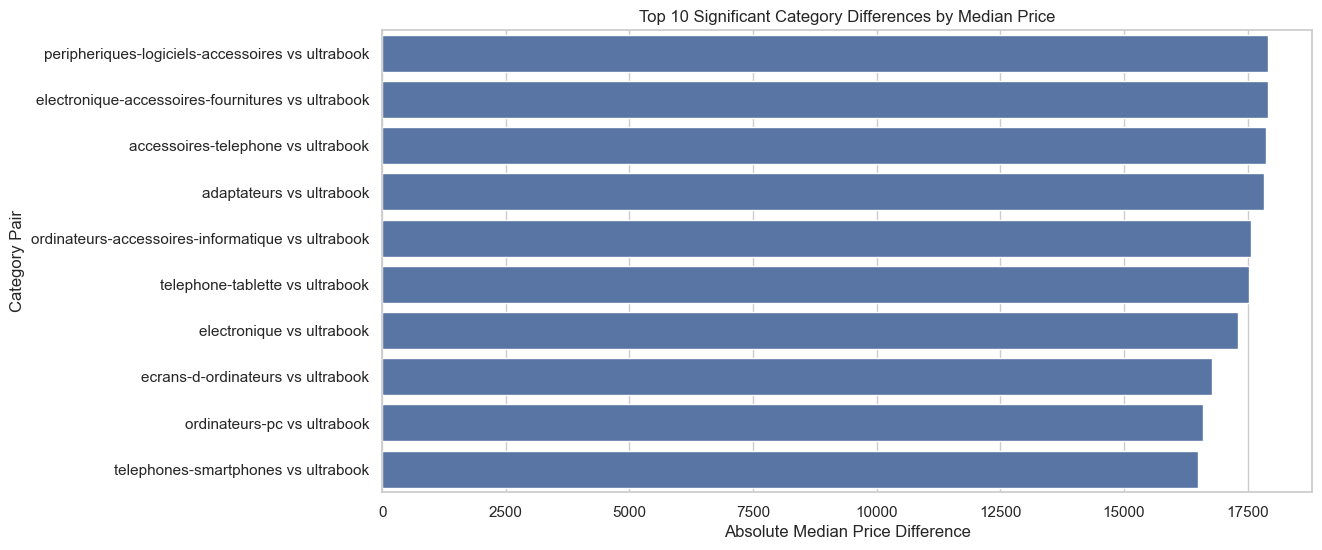

In [36]:
# Barplot of the 10 largest differences in median

top_posthoc = largest_median_differences.head(10).copy()

top_posthoc["comparison"] = (
    top_posthoc["category_1"] + " vs " + top_posthoc["category_2"]
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_posthoc,
    x="abs_median_difference",
    y="comparison"
)
plt.title("Top 10 Significant Category Differences by Median Price")
plt.xlabel("Absolute Median Price Difference")
plt.ylabel("Category Pair")
plt.show()

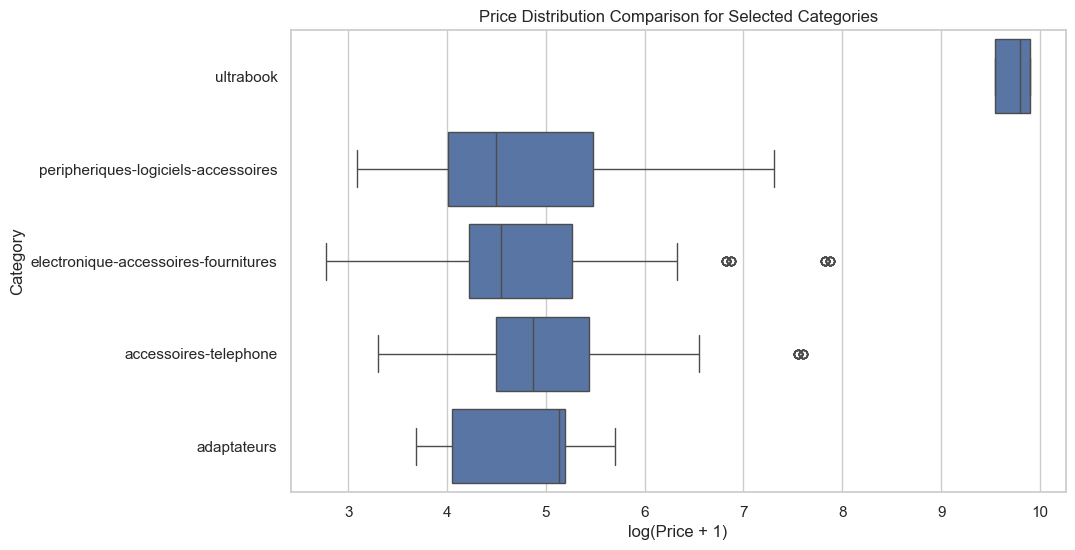

In [37]:
selected_categories = [
    "ultrabook",
    "peripheriques-logiciels-accessoires",
    "electronique-accessoires-fournitures",
    "accessoires-telephone",
    "adaptateurs"
]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean[df_clean["category"].isin(selected_categories)],
    x="log_price",
    y="category",
    order=selected_categories
)
plt.title("Price Distribution Comparison for Selected Categories")
plt.xlabel("log(Price + 1)")
plt.ylabel("Category")
plt.show()

In [38]:
"""The post-hoc analysis included 153 pairwise comparisons between the 18 product categories. After applying the Benjamini-Hochberg correction, 146 comparisons remained statistically significant, while only 7 were non-significant. This confirms that price distributions differ strongly across most product categories.

The largest median differences are observed between high-end categories such as `ultrabook` and lower-priced accessory categories such as `peripheriques-logiciels-accessoires`, `electronique-accessoires-fournitures`, and `accessoires-telephone`. For example, the median price difference between `peripheriques-logiciels-accessoires` and `ultrabook` is 17,910 MAD, and the adjusted p-value remains far below 0.05.

These results reinforce the conclusion that product category is a major driver of price differences in the dataset.

Statistical significance is assessed using the adjusted p-value. A comparison is considered significant when the adjusted p-value is below 0.05. The median difference is then used to interpret the direction and practical magnitude of the difference between the two categories."""

'The post-hoc analysis included 153 pairwise comparisons between the 18 product categories. After applying the Benjamini-Hochberg correction, 146 comparisons remained statistically significant, while only 7 were non-significant. This confirms that price distributions differ strongly across most product categories.\n\nThe largest median differences are observed between high-end categories such as `ultrabook` and lower-priced accessory categories such as `peripheriques-logiciels-accessoires`, `electronique-accessoires-fournitures`, and `accessoires-telephone`. For example, the median price difference between `peripheriques-logiciels-accessoires` and `ultrabook` is 17,910 MAD, and the adjusted p-value remains far below 0.05.\n\nThese results reinforce the conclusion that product category is a major driver of price differences in the dataset.\n\nStatistical significance is assessed using the adjusted p-value. A comparison is considered significant when the adjusted p-value is below 0.05. T

In [39]:
# Correlation Between Price, Rating, and Review Count

"""Because `rating` and `review_count` contain missing values, this analysis is performed only on observations where both variables are available.

Since the variables are not normally distributed, Spearman rank correlation is used instead of Pearson correlation."""

'Because `rating` and `review_count` contain missing values, this analysis is performed only on observations where both variables are available.\n\nSince the variables are not normally distributed, Spearman rank correlation is used instead of Pearson correlation.'

In [44]:
df_feedback = df_clean.dropna(
    subset=["price", "rating", "review_count", "scraped_at"]
).copy()

df_feedback["scraped_at"] = pd.to_datetime(df_feedback["scraped_at"])

df_feedback["days_since_start"] = (
    df_feedback["scraped_at"] - df_feedback["scraped_at"].min()
).dt.days

df_feedback["log_price"] = np.log1p(df_feedback["price"])
df_feedback["log_review_count"] = np.log1p(df_feedback["review_count"])

feedback_coverage = {
    "original_rows": len(df_clean),
    "feedback_rows": len(df_feedback),
    "retained_percentage": len(df_feedback) / len(df_clean) * 100,
    "min_date": df_feedback["scraped_at"].min(),
    "max_date": df_feedback["scraped_at"].max()
}

feedback_coverage

{'original_rows': 10523,
 'feedback_rows': 3523,
 'retained_percentage': 33.479045899458335,
 'min_date': Timestamp('2026-05-01 23:34:41.982628+0000', tz='UTC'),
 'max_date': Timestamp('2026-06-10 14:00:48.018154+0000', tz='UTC')}

In [51]:
# Spearman correlation

correlation_variables = [
    "price",
    "rating",
    "review_count",
    "days_since_start"
]

spearman_corr = df_feedback[correlation_variables].corr(method="spearman")

spearman_corr

,price,rating,review_count,days_since_start
price,1.000000,0.197300,-0.526226,-0.025832
rating,0.197300,1.000000,-0.297119,-0.036419
review_count,-0.526226,-0.297119,1.000000,-0.069417
days_since_start,-0.025832,-0.036419,-0.069417,1.000000


In [52]:
# Spearman  P-values

variables = ["price", "rating", "review_count", "days_since_start"]

spearman_results = []

for i in range(len(variables)):
    for j in range(i + 1, len(variables)):
        var1 = variables[i]
        var2 = variables[j]
        
        corr_result = stats.spearmanr(df_feedback[var1], df_feedback[var2])
        
        spearman_results.append({
            "variable_1": var1,
            "variable_2": var2,
            "spearman_correlation": corr_result.statistic,
            "p_value": corr_result.pvalue
        })

spearman_results_df = pd.DataFrame(spearman_results)

spearman_results_df

,variable_1,variable_2,spearman_correlation,p_value
0,price,rating,0.197300,2.971302e-32
1,price,review_count,-0.526226,3.242773e-250
2,price,days_since_start,-0.025832,1.252790e-01
3,rating,review_count,-0.297119,9.795032e-73
4,rating,days_since_start,-0.036419,3.065030e-02
5,review_count,days_since_start,-0.069417,3.727817e-05


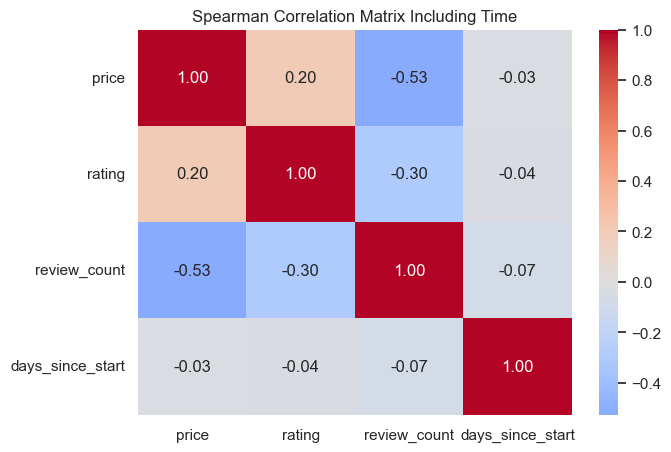

In [53]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Spearman Correlation Matrix Including Time")
plt.show()

In [54]:
regression_model = smf.ols(
    formula="price ~ rating + review_count + days_since_start",
    data=df_feedback
).fit()

print(regression_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     68.27
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           6.58e-43
Time:                        16:03:18   Log-Likelihood:                -29679.
No. Observations:                3523   AIC:                         5.937e+04
Df Residuals:                    3519   BIC:                         5.939e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          336.3665    123.360  

In [56]:
# log_price because price is very asymmetric. It's statistically cleaner.

regression_model = smf.ols(
    formula="log_price ~ rating + log_review_count + days_since_start",
    data=df_feedback
).fit()

print(regression_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     484.2
Date:                Thu, 11 Jun 2026   Prob (F-statistic):          2.19e-263
Time:                        16:17:33   Log-Likelihood:                -5579.1
No. Observations:                3523   AIC:                         1.117e+04
Df Residuals:                    3519   BIC:                         1.119e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            6.8836      0.144  

In [57]:
# Linear Regression: Price as a Function of Rating, Reviews, and Time

"""To align with the project requirement, a regression model is built to explain product price using rating, review count, and time.

The timestamp variable `scraped_at` is transformed into `days_since_start`. Because the price distribution is highly skewed, the dependent variable is log-transformed."""

'To align with the project requirement, a regression model is built to explain product price using rating, review count, and time.\n\nThe timestamp variable `scraped_at` is transformed into `days_since_start`. Because the price distribution is highly skewed, the dependent variable is log-transformed.'

In [58]:
df_feedback["log_price"] = np.log1p(df_feedback["price"])
df_feedback["log_review_count"] = np.log1p(df_feedback["review_count"])

In [59]:
regression_model = smf.ols(
    formula="log_price ~ rating + log_review_count + days_since_start",
    data=df_feedback
).fit()

print(regression_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     484.2
Date:                Thu, 11 Jun 2026   Prob (F-statistic):          2.19e-263
Time:                        16:20:13   Log-Likelihood:                -5579.1
No. Observations:                3523   AIC:                         1.117e+04
Df Residuals:                    3519   BIC:                         1.119e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            6.8836      0.144  

In [60]:
regression_summary = {
    "r_squared": regression_model.rsquared,
    "adj_r_squared": regression_model.rsquared_adj,
    "f_statistic": regression_model.fvalue,
    "f_p_value": regression_model.f_pvalue,
    "n_observations": int(regression_model.nobs)
}

regression_summary

{'r_squared': np.float64(0.2921857574203114),
 'adj_r_squared': np.float64(0.29158233521862365),
 'f_statistic': np.float64(484.21446311238765),
 'f_p_value': np.float64(2.1946927108532255e-263),
 'n_observations': 3523}

In [61]:
regression_coefficients = pd.DataFrame({
    "coefficient": regression_model.params,
    "p_value": regression_model.pvalues,
    "conf_low": regression_model.conf_int()[0],
    "conf_high": regression_model.conf_int()[1]
})

regression_coefficients

,coefficient,p_value,conf_low,conf_high
Intercept,6.883593,0.000000e+00,6.600846,7.166341
rating,0.064875,3.302519e-02,0.005232,0.124518
log_review_count,-0.647178,3.524612e-253,-0.681491,-0.612864
days_since_start,-0.009536,1.100495e-09,-0.012596,-0.006477


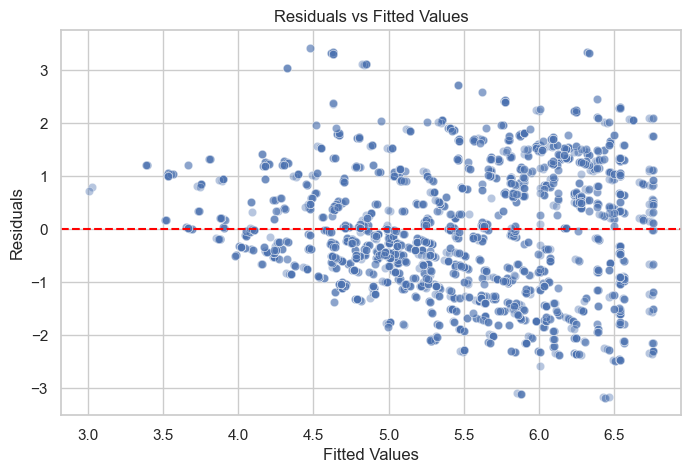

In [62]:
# Residue Simple Diagnosis

residuals = regression_model.resid
fitted_values = regression_model.fittedvalues

plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

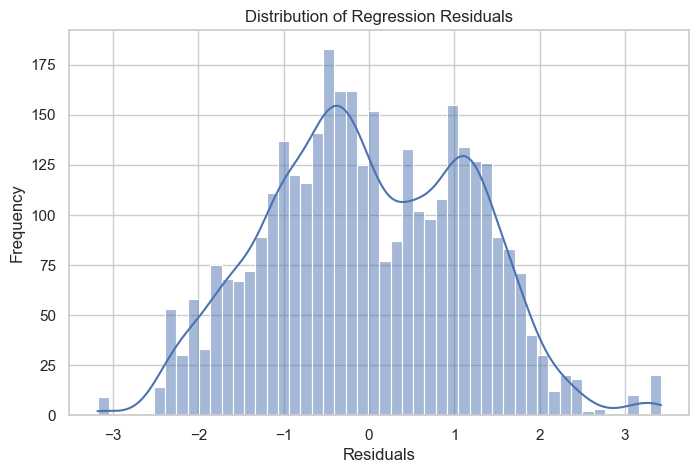

In [63]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Distribution of Regression Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

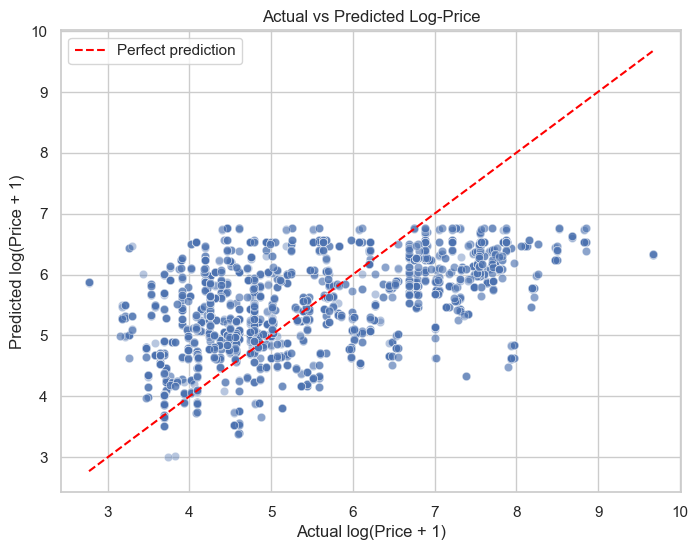

In [66]:
df_feedback["predicted_log_price"] = regression_model.predict(df_feedback)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_feedback["log_price"],
    y=df_feedback["predicted_log_price"],
    alpha=0.4
)

min_value = min(df_feedback["log_price"].min(), df_feedback["predicted_log_price"].min())
max_value = max(df_feedback["log_price"].max(), df_feedback["predicted_log_price"].max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.title("Actual vs Predicted Log-Price")
plt.xlabel("Actual log(Price + 1)")
plt.ylabel("Predicted log(Price + 1)")
plt.legend()
plt.show()

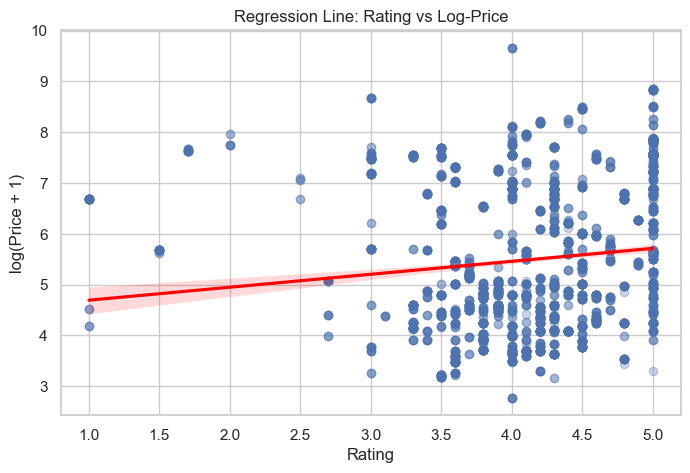

In [67]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_feedback,
    x="rating",
    y="log_price",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)
plt.title("Regression Line: Rating vs Log-Price")
plt.xlabel("Rating")
plt.ylabel("log(Price + 1)")
plt.show()

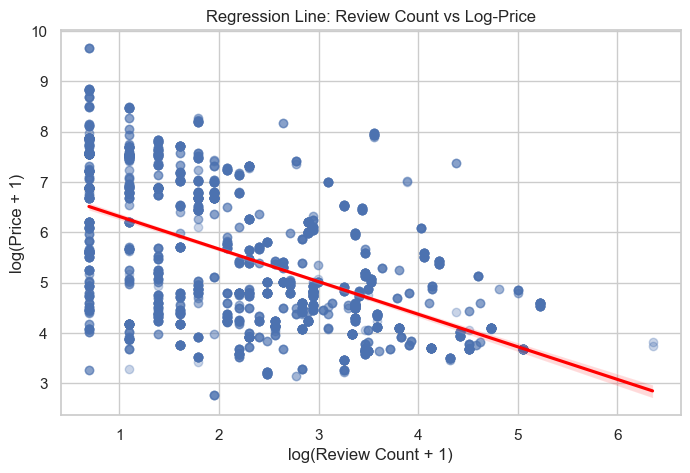

In [68]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_feedback,
    x="log_review_count",
    y="log_price",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)
plt.title("Regression Line: Review Count vs Log-Price")
plt.xlabel("log(Review Count + 1)")
plt.ylabel("log(Price + 1)")
plt.show()

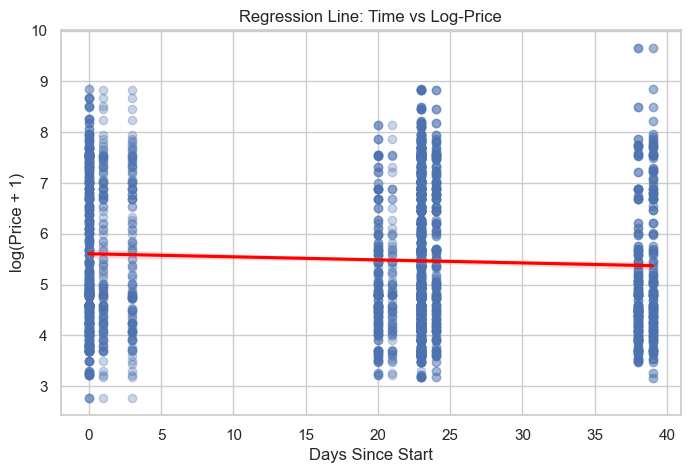

In [69]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_feedback,
    x="days_since_start",
    y="log_price",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)
plt.title("Regression Line: Time vs Log-Price")
plt.xlabel("Days Since Start")
plt.ylabel("log(Price + 1)")
plt.show()

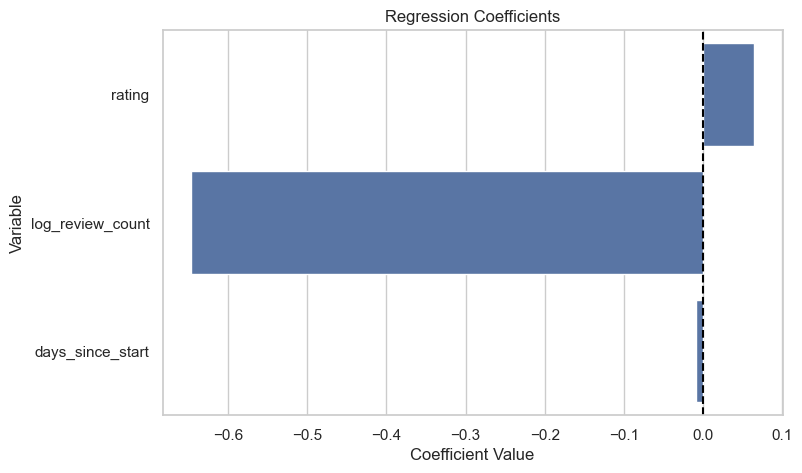

In [70]:
# Visualizing the coefficients

coef_plot_df = regression_coefficients.reset_index().rename(columns={"index": "variable"})
coef_plot_df = coef_plot_df[coef_plot_df["variable"] != "Intercept"]

plt.figure(figsize=(8, 5))
sns.barplot(
    data=coef_plot_df,
    x="coefficient",
    y="variable"
)

plt.axvline(0, color="black", linestyle="--")
plt.title("Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Variable")
plt.show()

In [64]:
# Bonus: model with category (because analysis showed that category strongly influence prices)

regression_model_with_category = smf.ols(
    formula="log_price ~ rating + log_review_count + days_since_start + C(category)",
    data=df_feedback
).fit()

print(regression_model_with_category.summary())



                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     696.1
Date:                Thu, 11 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:28:41   Log-Likelihood:                -4042.6
No. Observations:                3523   AIC:                             8111.
Df Residuals:                    3510   BIC:                             8191.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

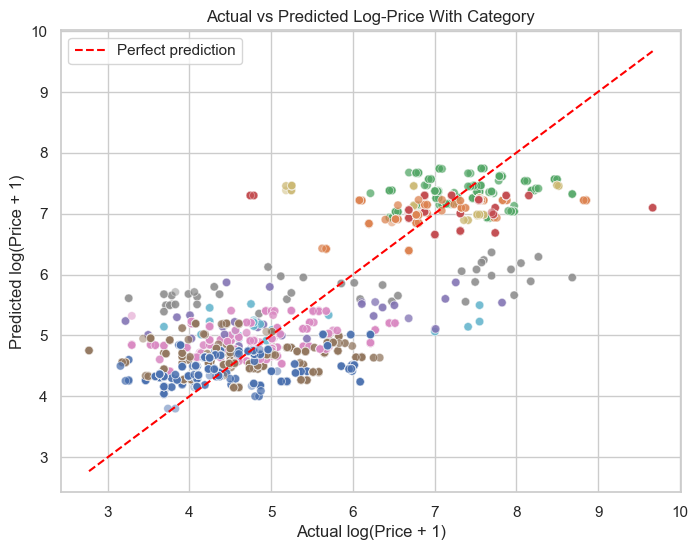

In [71]:
df_feedback["predicted_log_price_with_category"] = regression_model_with_category.predict(df_feedback)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_feedback["log_price"],
    y=df_feedback["predicted_log_price_with_category"],
    hue=df_feedback["category"],
    alpha=0.5,
    legend=False
)

min_value = min(
    df_feedback["log_price"].min(),
    df_feedback["predicted_log_price_with_category"].min()
)

max_value = max(
    df_feedback["log_price"].max(),
    df_feedback["predicted_log_price_with_category"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.title("Actual vs Predicted Log-Price With Category")
plt.xlabel("Actual log(Price + 1)")
plt.ylabel("Predicted log(Price + 1)")
plt.legend()
plt.show()

In [65]:
# Comparison with and without category

model_comparison = pd.DataFrame({
    "model": ["without_category", "with_category"],
    "r_squared": [regression_model.rsquared, regression_model_with_category.rsquared],
    "adj_r_squared": [regression_model.rsquared_adj, regression_model_with_category.rsquared_adj],
    "aic": [regression_model.aic, regression_model_with_category.aic],
    "bic": [regression_model.bic, regression_model_with_category.bic]
})

model_comparison

,model,r_squared,adj_r_squared,aic,bic
0,without_category,0.292186,0.291582,11166.261026,11190.929299
1,with_category,0.704135,0.703124,8111.222893,8191.394780


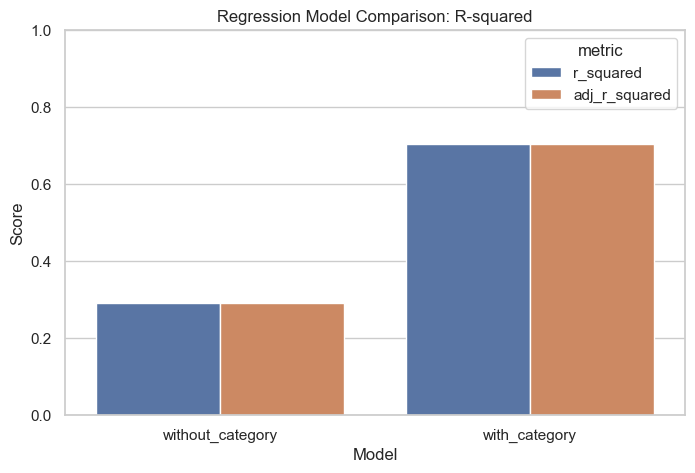

In [75]:
# R_squared

model_comparison_melted = model_comparison.melt(
    id_vars="model",
    value_vars=["r_squared", "adj_r_squared"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=model_comparison_melted,
    x="model",
    y="value",
    hue="metric"
)

plt.title("Regression Model Comparison: R-squared")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

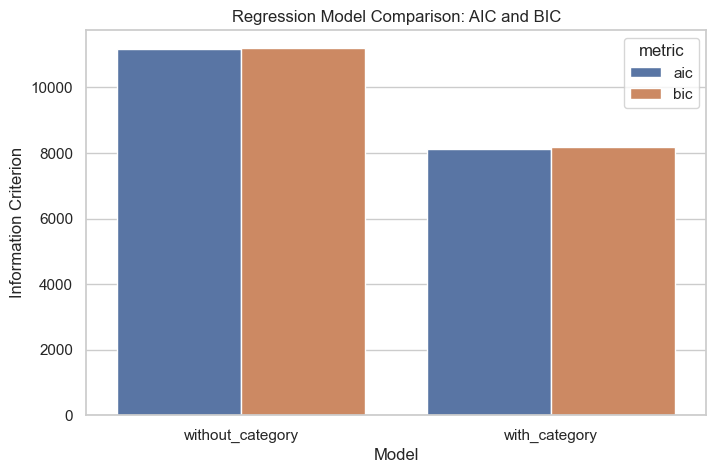

In [76]:
# Barplot AIC / BIC

model_comparison_ic = model_comparison.melt(
    id_vars="model",
    value_vars=["aic", "bic"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=model_comparison_ic,
    x="model",
    y="value",
    hue="metric"
)

plt.title("Regression Model Comparison: AIC and BIC")
plt.xlabel("Model")
plt.ylabel("Information Criterion")
plt.show()

In [77]:
"""The comparison between the two regression models shows that adding product category substantially improves model performance. The R-squared increases from approximately 0.29 to 0.70, meaning that the model with category explains about 70% of the variation in log-transformed prices.

The adjusted R-squared also increases, which indicates that the improvement is not only due to adding more variables. In addition, both AIC and BIC decrease strongly in the model with category, suggesting a better balance between model fit and complexity.

This confirms that product category is a major determinant of price in the dataset, beyond rating, review count, and time."""

'The comparison between the two regression models shows that adding product category substantially improves model performance. The R-squared increases from approximately 0.29 to 0.70, meaning that the model with category explains about 70% of the variation in log-transformed prices.\n\nThe adjusted R-squared also increases, which indicates that the improvement is not only due to adding more variables. In addition, both AIC and BIC decrease strongly in the model with category, suggesting a better balance between model fit and complexity.\n\nThis confirms that product category is a major determinant of price in the dataset, beyond rating, review count, and time.'

In [78]:
# Confidence Intervals

#Confidence intervals are used to estimate the uncertainty around key statistical estimates. Since price distributions are highly skewed, bootstrap confidence intervals are used for robust estimation.

In [79]:
# Bootstrap CI for the average price per site

def bootstrap_ci(data, statistic=np.mean, n_bootstrap=5000, confidence_level=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    data = np.array(data.dropna())
    
    bootstrap_stats = []
    
    for _ in range(n_bootstrap):
        sample = rng.choice(data, size=len(data), replace=True)
        bootstrap_stats.append(statistic(sample))
    
    alpha = 1 - confidence_level
    lower = np.percentile(bootstrap_stats, 100 * alpha / 2)
    upper = np.percentile(bootstrap_stats, 100 * (1 - alpha / 2))
    
    return lower, upper

In [80]:
site_confidence_intervals = []

for site in df_clean["site_name"].unique():
    site_prices = df_clean[df_clean["site_name"] == site]["price"]
    
    mean_ci = bootstrap_ci(site_prices, statistic=np.mean)
    median_ci = bootstrap_ci(site_prices, statistic=np.median)
    
    site_confidence_intervals.append({
        "site_name": site,
        "mean_price": site_prices.mean(),
        "mean_ci_lower": mean_ci[0],
        "mean_ci_upper": mean_ci[1],
        "median_price": site_prices.median(),
        "median_ci_lower": median_ci[0],
        "median_ci_upper": median_ci[1]
    })

site_ci_df = pd.DataFrame(site_confidence_intervals)

site_ci_df

,site_name,mean_price,mean_ci_lower,mean_ci_upper,median_price,median_ci_lower,median_ci_upper
0,electroplanet,7584.261538,7043.906795,8140.129615,5999.0,5499.0,7399.0
1,jumia_ma,1461.277808,1418.143947,1504.097948,959.0,875.0,969.0


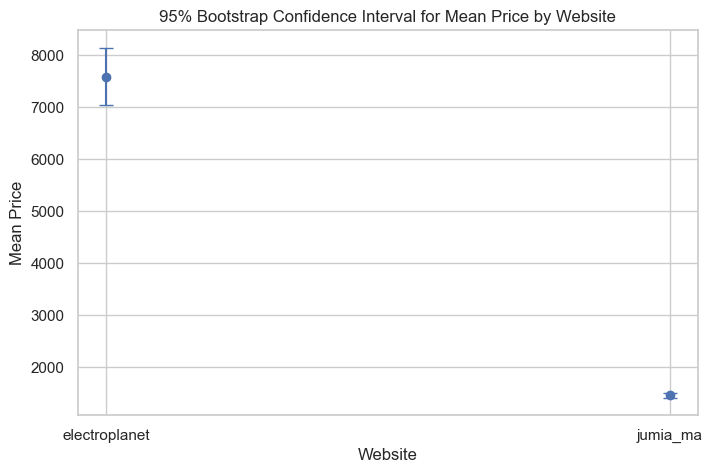

In [81]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    x=site_ci_df["site_name"],
    y=site_ci_df["mean_price"],
    yerr=[
        site_ci_df["mean_price"] - site_ci_df["mean_ci_lower"],
        site_ci_df["mean_ci_upper"] - site_ci_df["mean_price"]
    ],
    fmt="o",
    capsize=5
)

plt.title("95% Bootstrap Confidence Interval for Mean Price by Website")
plt.xlabel("Website")
plt.ylabel("Mean Price")
plt.show()

In [82]:
# Bootstrap confidence intervals were used because the price distribution is skewed and contains extreme values. The confidence intervals provide an estimated range for the mean and median prices of each website while accounting for sampling variability.

In [83]:
# Power Analysis

# Power analysis evaluates whether the sample size is sufficient to detect a difference between groups. Here, power analysis is performed for the website price comparison using log-transformed prices.

In [84]:
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans

In [89]:
jumia_log_prices = df_clean[df_clean["site_name"] == "jumia_ma"]["log_price"].dropna()
electroplanet_log_prices = df_clean[df_clean["site_name"] == "electroplanet"]["log_price"].dropna()

mean_diff = electroplanet_log_prices.mean() - jumia_log_prices.mean()

pooled_std = np.sqrt(
    ((len(jumia_log_prices) - 1) * jumia_log_prices.var() +
     (len(electroplanet_log_prices) - 1) * electroplanet_log_prices.var()) /
    (len(jumia_log_prices) + len(electroplanet_log_prices) - 2)
)

effect_size = mean_diff / pooled_std

power_analysis = TTestIndPower()

statistical_power = power_analysis.power(
    effect_size=abs(effect_size),
    nobs1=len(electroplanet_log_prices),
    ratio=len(jumia_log_prices) / len(electroplanet_log_prices),
    alpha=0.05
)

power_results = {
    "effect_size_cohens_d_log_price": effect_size,
    "n_jumia": len(jumia_log_prices),
    "n_electroplanet": len(electroplanet_log_prices),
    "alpha": 0.05,
    "statistical_power": statistical_power
}

power_results

{'effect_size_cohens_d_log_price': np.float64(1.3902539358069992),
 'n_jumia': 9938,
 'n_electroplanet': 585,
 'alpha': 0.05,
 'statistical_power': np.float64(nan)}

In [90]:
required_n_per_group = power_analysis.solve_power(
    effect_size=abs(effect_size),
    power=0.80,
    alpha=0.05,
    ratio=1.0,
    alternative="two-sided"
)

power_results_alternative = {
    "effect_size_cohens_d_log_price": effect_size,
    "required_n_per_group_for_80_power": required_n_per_group,
    "actual_n_jumia": n_jumia,
    "actual_n_electroplanet": n_electroplanet
}

power_results_alternative

{'effect_size_cohens_d_log_price': np.float64(1.3902539358069992),
 'required_n_per_group_for_80_power': 9.188931249006554,
 'actual_n_jumia': 9938,
 'actual_n_electroplanet': 585}

In [92]:
"""The power analysis shows that the observed effect size between Jumia and Electroplanet log-prices is very large (Cohen's d = 1.39). Based on this effect size, approximately 10 observations per group would be required to achieve 80% statistical power at alpha = 0.05.

The available sample sizes are much larger, with 9,938 observations for Jumia and 585 observations for Electroplanet. Therefore, the dataset is sufficiently powered to detect the observed difference between the two platforms.

Because the direct power calculation returned a numerical instability (`NaN`), the analysis was reported using the required sample size for 80% power, which is more stable and easier to interpret in this case."""

"The power analysis shows that the observed effect size between Jumia and Electroplanet log-prices is very large (Cohen's d = 1.39). Based on this effect size, approximately 10 observations per group would be required to achieve 80% statistical power at alpha = 0.05.\n\nThe available sample sizes are much larger, with 9,938 observations for Jumia and 585 observations for Electroplanet. Therefore, the dataset is sufficiently powered to detect the observed difference between the two platforms.\n\nBecause the direct power calculation returned a numerical instability (`NaN`), the analysis was reported using the required sample size for 80% power, which is more stable and easier to interpret in this case."

In [93]:
## Inferential Statistics Summary

"""The inferential statistical analysis provides evidence that price differences in the dataset are statistically significant across websites and product categories.

First, the Shapiro-Wilk test showed that both raw prices and log-transformed prices do not follow a normal distribution. Therefore, non-parametric tests were selected for group comparisons.

The Mann-Whitney U test showed a statistically significant difference between the price distributions of Jumia Morocco and Electroplanet. Electroplanet has a much higher median price than Jumia Morocco in the observed dataset. However, this result should be interpreted carefully because the two platforms have different catalog compositions and imbalanced sample sizes.

The Kruskal-Wallis test showed a statistically significant difference in price distributions across product categories. Post-hoc pairwise Mann-Whitney tests with Benjamini-Hochberg correction confirmed that most category pairs differ significantly. The largest differences were observed between premium computer categories such as `ultrabook`, `pc-gamer`, and `pc-hybride`, and lower-priced accessory categories such as `peripheriques-logiciels-accessoires`, `electronique-accessoires-fournitures`, and `accessoires-telephone`.

The correlation analysis showed a weak positive relationship between price and rating, and a moderate negative relationship between price and review count. This suggests that higher-priced products tend to have slightly higher ratings, while products with more reviews tend to be lower-priced. The relationship between price and time was weak and not statistically significant in the feedback subset.

The regression model using rating, review count, and time explained approximately 29% of the variation in log-transformed prices. Adding product category improved the model substantially, increasing the R-squared to approximately 70%. This confirms that product category is a major determinant of price in the dataset.

Bootstrap confidence intervals showed that Electroplanet has a substantially higher estimated mean and median price than Jumia Morocco. The confidence intervals for mean prices do not overlap, supporting the conclusion that the observed price difference between platforms is meaningful.

Finally, the power analysis showed that the observed effect size between Jumia and Electroplanet log-prices is very large. The available sample sizes are more than sufficient to detect this difference with adequate statistical power.

Overall, the inferential analysis confirms that website, product category, review count, rating, and time contribute differently to price behavior, with product category being the strongest explanatory factor."""

'The inferential statistical analysis provides evidence that price differences in the dataset are statistically significant across websites and product categories.\n\nFirst, the Shapiro-Wilk test showed that both raw prices and log-transformed prices do not follow a normal distribution. Therefore, non-parametric tests were selected for group comparisons.\n\nThe Mann-Whitney U test showed a statistically significant difference between the price distributions of Jumia Morocco and Electroplanet. Electroplanet has a much higher median price than Jumia Morocco in the observed dataset. However, this result should be interpreted carefully because the two platforms have different catalog compositions and imbalanced sample sizes.\n\nThe Kruskal-Wallis test showed a statistically significant difference in price distributions across product categories. Post-hoc pairwise Mann-Whitney tests with Benjamini-Hochberg correction confirmed that most category pairs differ significantly. The largest diffe

In [94]:
## Limitations

"""Several limitations should be considered when interpreting these results. First, the dataset is imbalanced between websites, with many more observations from Jumia Morocco than from Electroplanet. Second, product catalogs are not identical across platforms, which means that platform-level price comparisons may partly reflect differences in product mix rather than pure pricing strategy.

Third, `rating` and `review_count` contain many missing values, so analyses involving these variables were performed only on complete cases. This may introduce selection bias if products with available ratings and reviews differ systematically from those without them.

Finally, the time period covers approximately six weeks, which is useful for short-term price monitoring but may not capture longer-term seasonal trends."""

'Several limitations should be considered when interpreting these results. First, the dataset is imbalanced between websites, with many more observations from Jumia Morocco than from Electroplanet. Second, product catalogs are not identical across platforms, which means that platform-level price comparisons may partly reflect differences in product mix rather than pure pricing strategy.\n\nThird, `rating` and `review_count` contain many missing values, so analyses involving these variables were performed only on complete cases. This may introduce selection bias if products with available ratings and reviews differ systematically from those without them.\n\nFinally, the time period covers approximately six weeks, which is useful for short-term price monitoring but may not capture longer-term seasonal trends.'